__WEBSITE, WHICH HELPED ME WITH THIS PROJECT:__

* https://www.geeksforgeeks.org/machine-learning/image-classifier-using-cnn/
* https://www.geeksforgeeks.org/deep-learning/cifar-10-image-classification-in-tensorflow/
* https://www.tensorflow.org/tutorials/images/cnn
* https://keras.io/api/callbacks/early_stopping/
* https://keras.io/api/callbacks/model_checkpoint/
* https://www.kaggle.com/code/farzadnekouei/cifar-10-image-classification-with-cnn
* https://www.slingacademy.com/article/tensorflow-random-setting-random-seeds-for-reproducibility/

# 1. Step: IMPORT LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Import all necessary libraries, which will be used during this project.

# 2. Step: LOAD CIFAR-10 DATASET

In [2]:
print("LOADING CIFAR-10 DATASET")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Define class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Display dataset information
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")

LOADING CIFAR-10 DATASET
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Dataset contains together 60 000 color images of size 32×32 pixels. We load the data into 50,000 training images and 10,000 test images. 

We defined classes names such as:
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

Each class contains 6,000 images, making the dataset perfectly balanced.

# 3. Step: DATA PREPROCESSING

In [3]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
y_train_categorical = to_categorical(y_train, num_classes=10)
y_test_categorical = to_categorical(y_test, num_classes=10)

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train_categorical.shape}")
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Pixel value range: [0.0, 1.0]


We change the pixel value range from 0-255 to 0-1 and converted the float type from 64 to 32. These actions should help with training stability, model performance and memory usage. Creating binary vector via one-hot encoding is essential for further the categorical crossentropy loss function. It also allows to eliminate possible false ordinal relationship such as, cat(4) is lower than deer(5).

# 4. Step: CREATE DATA

In [4]:
# For training data with augmentation
train_dataGenerator = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    fill_mode="nearest"
)

# For validation data (no augmentation)
validation_dataGenerator = ImageDataGenerator()

# Use flow() method
batch_size = 64

trainDatasets = train_dataGenerator.flow(
    x_train, 
    y_train_categorical,
    batch_size=batch_size,
    shuffle=True
)

validationDatasets = validation_dataGenerator.flow(
    x_test,
    y_test_categorical,
    batch_size=batch_size,
    shuffle=False
)

# Calculate steps properly
classSamplesT = len(x_train)
classSamplesV = len(x_test)
steps_per_epoch = max(1, classSamplesT // batch_size)
validation_steps = max(1, classSamplesV // batch_size)

print(f"Batch size: {batch_size}")
print(f"Training samples: {classSamplesT}")
print(f"Validation samples: {classSamplesV}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")


Batch size: 64
Training samples: 50000
Validation samples: 10000
Steps per epoch: 781
Validation steps: 156


train_dataGenerator contains augmentation techniques such as shear, zoom, width/height shifts, horizontal flips, and rotationcontains were chosen based on actively trying to find the best configuration. This version serves to prevent overfitting. On the other hand, the validation generator only applies rescaling, because augmentitation would mask the true performance. Batch size was set to be 64 - to have more balance memory and proper training speed. Flow serves as a bridge between in-memory data and the ImageDataGenerator. It also shuffle the training dataset to prevent possible bias and learns actual patern. Lastly we had to calculate the steps properly, meaning how many batches to process before completing one epoch.

# 5. Step: BUILD CNN MODEL

In [5]:
model = Sequential()

# Input layer FIRST
model.add(Input(shape=(32, 32, 3)))

# CONV 01 Layer
model.add(Conv2D(32, (3, 3), padding="same", strides=(1, 1), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="valid"))
model.add(BatchNormalization())

# CONV 02 Layer
model.add(Conv2D(64, (3, 3), padding="same", strides=(1, 1), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="valid"))
model.add(BatchNormalization())

# CONV 03 Layer
model.add(Conv2D(128, (3, 3), padding="same", strides=(1, 1), activation="relu"))
model.add(BatchNormalization())

# CONV 04 Layer
model.add(Conv2D(128, (3, 3), padding="same", strides=(1, 1), activation="relu"))
model.add(BatchNormalization())

# CONV 05 Layer
model.add(Conv2D(256, (3, 3), padding="same", strides=(1, 1), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="valid"))
model.add(BatchNormalization())

# Flatten Layer
model.add(Flatten())

# Dense 01
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.3))
model.add(BatchNormalization())

# Dense 02
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.3))
model.add(BatchNormalization())

# Final Layer
model.add(Dense(10, activation="softmax"))

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,773,066 (10.58 MB)

 Trainable params: 2,770,314 (10.57 MB)

 Non-trainable params: 2,752 (10.75 KB)

Now we have a complete CNN model, which can classify small 32×32 color images. It is done by choosing a model to be sequential, which means it is linear and each layer feeds directly into the next. We set up the input shape to be (32, 32, 3) because the images have the same values. We have 5 Convolutional Layers. The difference between them is the increasing filter count from 32 to 256. It can then receive complex patterns. MaxPooling was used in some layers to reduce spatial size. In almost every layer, we used Batch Normalization to make training faster and more stable. We are adding a flatten layer, which is used for dense layers to change the 2D feature maps to a 1D vector, and they are used to connect the neurons. We are also implementing dropout, which is randomly dropping neurons to prevent overfitting. Lastly, we used Softmax for multi-class classification. It converts numbers into probabilities.

# 6. Step: COMPILE MODEL

In [6]:
# Adam optimizer 
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


Adam optimizer was selected with a learning rate of 0.001 for model compilation. It should be able to control the speed, direction, and method of learning from errors. Categorical_crossentropy was ideal to choose for the loss function, because it can measure wrong predictions for multiple classes. Lastly, we chose to use accuracy as the main progress indicator. It will be able to show us correct predictions in percentage.

# 7. Step: SET UP CALLBACKS

In [7]:
# Model checkpoint
weightPath = "best_weights_cifar10.weights.h5"
checkPoint = ModelCheckpoint(
    weightPath, 
    monitor="val_accuracy", 
    verbose=1, 
    save_best_only=True, 
    save_weights_only=True, 
    mode="max"
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

callBacksList = [checkPoint, early_stop]

print(f"Checkpoint path: {weightPath}")
print("Callbacks: ModelCheckpoint, EarlyStopping")

Checkpoint path: best_weights_cifar10.weights.h5
Callbacks: ModelCheckpoint, EarlyStopping


__checkPoint:__

    It saves the model's weights when the accuracy improves.

__early_stop:__

    Stops the training once the model is not improving after 5 epochs and saves the best performance

__callBacksList:__

    It combines both callbacks and will be used in the next step


# 8. Step: TRAIN MODEL

In [8]:
epochs = 30

print(f"Batch size: {batch_size}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print(f"Epochs: {epochs}")
print("\nStarting training...\n")

history = model.fit(
    trainDatasets,
    steps_per_epoch=steps_per_epoch,
    validation_data=validationDatasets,
    epochs=epochs,
    validation_steps=validation_steps,
    callbacks=callBacksList,
    verbose=1
)

print("\nTraining completed!")

Batch size: 64
Steps per epoch: 781
Validation steps: 156
Epochs: 30

Starting training...

Epoch 1/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3278 - loss: 1.9662 
Epoch 1: val_accuracy improved from None to 0.48728, saving model to best_weights_cifar10.weights.h5

Epoch 1: finished saving model to best_weights_cifar10.weights.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.4022 - loss: 1.6937 - val_accuracy: 0.4873 - val_loss: 1.5800
Epoch 2/30
  1/781 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.5000 - loss: 1.1979
Epoch 2: val_accuracy improved from 0.48728 to 0.50671, saving model to best_weights_cifar10.weights.h5

Epoch 2: finished saving model to best_weights_cifar10.weights.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5000 - loss: 1.1979 - val_accuracy: 0.5067 - val_loss: 1.5036
Epoch 3/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5226 - loss: 1.3318 
Epoch 3: val_accuracy improved from 0.50671 to 0.57722, saving model 

The training model was set up to complete 30 epochs. At the moment, it complete each epoch. There were moments when the training model stopped the training before each epoch was completed, because it was not improving. Therefore, we know the callback works, but it was not used in this case.

# 9. Step: PLOT TRAINING RESULTS

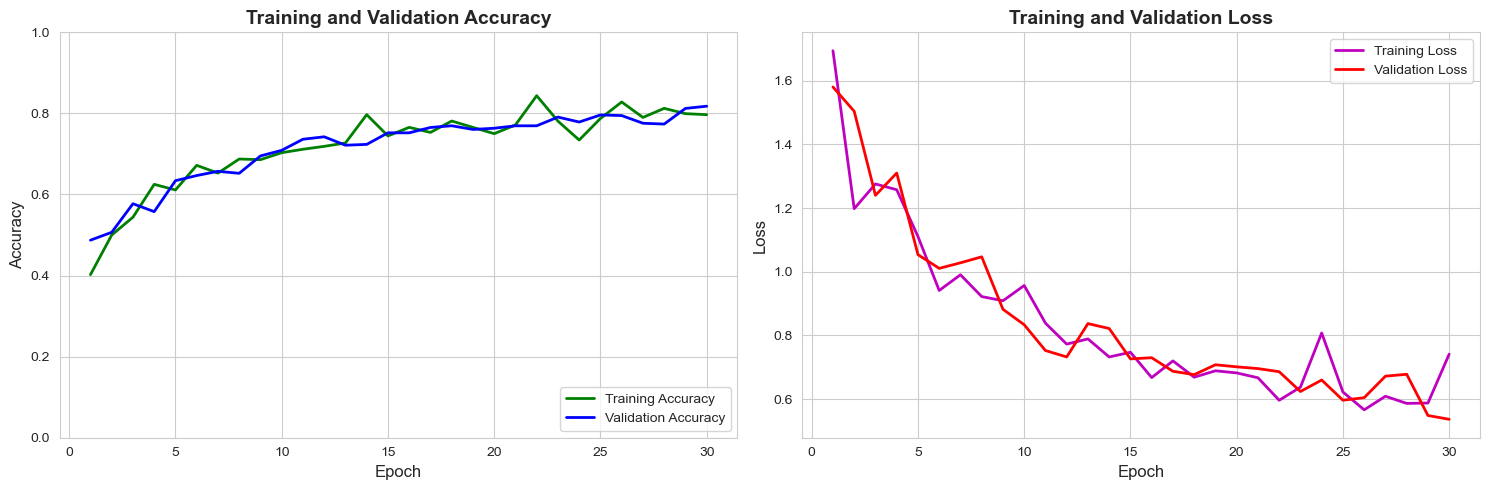


Best Results:
  Best Validation Accuracy: 0.8178 at epoch 30
  Best Training Accuracy: 0.7969


In [9]:
# Set style
sns.set_style("whitegrid")

# Get history values
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

# Create figure
plt.figure(figsize=(15, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'g-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, 'b-', label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.ylim([0, 1])

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'm-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print best results
best_epoch = np.argmax(val_acc)
print(f"\nBest Results:")
print(f"  Best Validation Accuracy: {val_acc[best_epoch]:.4f} at epoch {best_epoch + 1}")
print(f"  Best Training Accuracy: {acc[best_epoch]:.4f}")

Based on the results, we can see two plots and the best validation and training accuracy numbers. 

The left plot shows two curves that are close to each other. The training accuracy ranged from 0.40 to 0.80, and the validation accuracy ranged from 0.48 to 0.82. After epoch 20, we can see just a slight improvement. 

The right plot shows two curves with training and validation loss. Almost with each epoch is decreasing, which is a good sign of having no overfitting. The small fluctuations are okay and normal.

Overall, the model is learning properly. It confirms there is no overfitting or underfitting. The model is good enough to use, in my opinion.

# 10. Step: EVALUATE MODEL

In [10]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Loss: 0.5367
Test Accuracy: 0.8179 (81.79%)


The model was tested on unseen data. The Test Loss is 0.54 and the Test Accuracy is 81.79%. This is a good sign of prediction confidence and a well-designed model. The performance confirms similar results with validation accuracy.

# 11. Step: CLASSIFICATION REPORT

In [11]:
# Make predictions
predictions = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)

# Generate classification report
print("\nClassification Report:")
print("-" * 60)
print(classification_report(y_true, y_pred_classes, target_names=class_names))


Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.80      0.84      0.82      1000
  automobile       0.90      0.92      0.91      1000
        bird       0.88      0.69      0.78      1000
         cat       0.72      0.62      0.67      1000
        deer       0.78      0.82      0.80      1000
         dog       0.80      0.71      0.75      1000
        frog       0.83      0.87      0.85      1000
       horse       0.85      0.86      0.85      1000
        ship       0.82      0.94      0.88      1000
       truck       0.81      0.90      0.85      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



Based on the report, we know that the class of dog, bird and especially cat is struggling a bit. The best performing class is automobile with a precision 90% and a recall 92%, which means most of the automobile images will be correctly identified. The ship is also easy to classify because it has a recall 94%. With 10 000 images, the overall accuracy is 82%.

# 12. Step: CONFUSION MATRIX

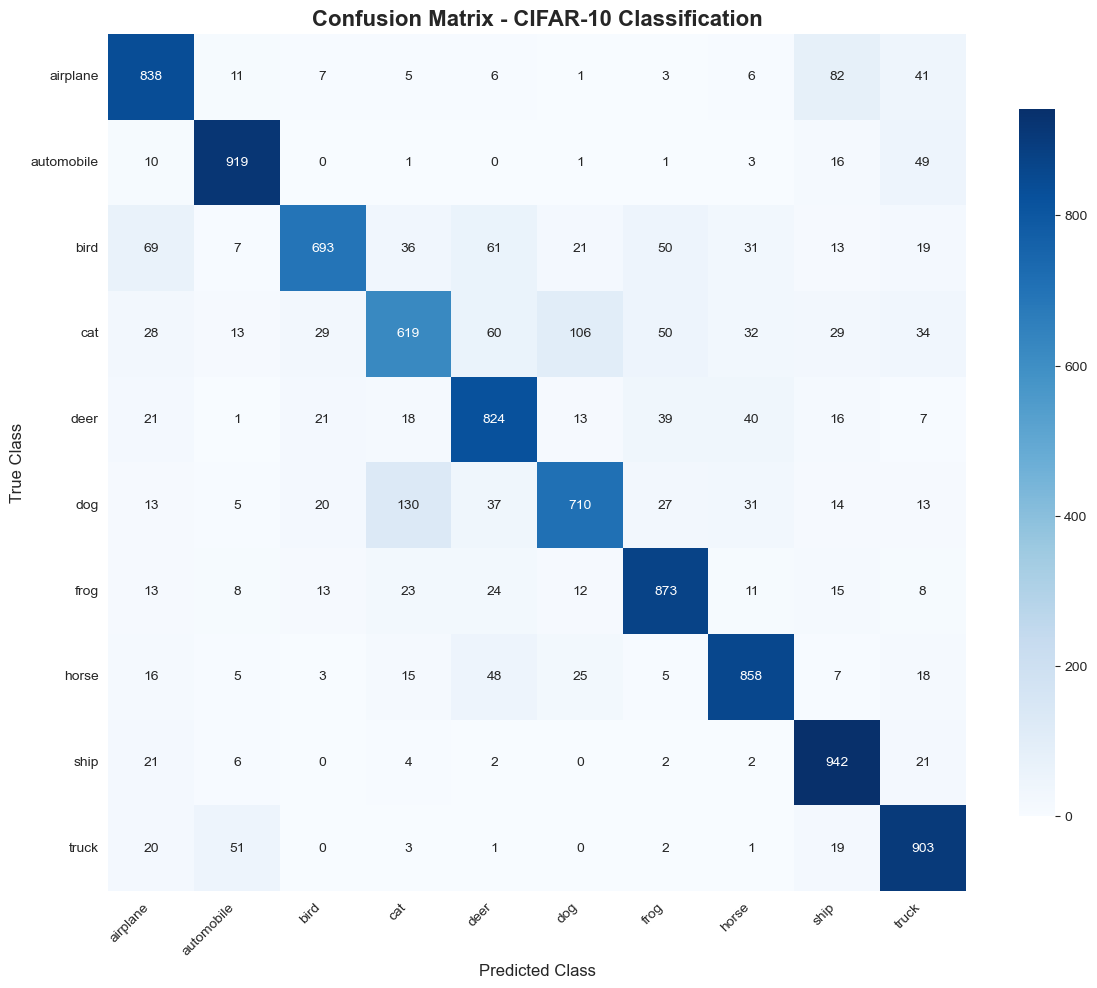

In [12]:
# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Confusion Matrix - CIFAR-10 Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

This is a confusion matrix that visually shows the predictions of each class. Most of the class shows high correct predictions (ranging from 700 to 900). We can visually see that the ship, automobile, truck, frog, and horse show high prediction accuracy. Misclassification concerns mainly the bird, cat, and dog classes. 

Overall, the model is reliable. It is confused mainly with cat and dog classes. The bird class is confused across all the predictions, but mainly with airplane (69), deer (61), and frog(50). The best predicted class is ship. Errors come from similar-looking objects, which is understandable.

# 13. Step: PREDICT A SINGLE IMAGE

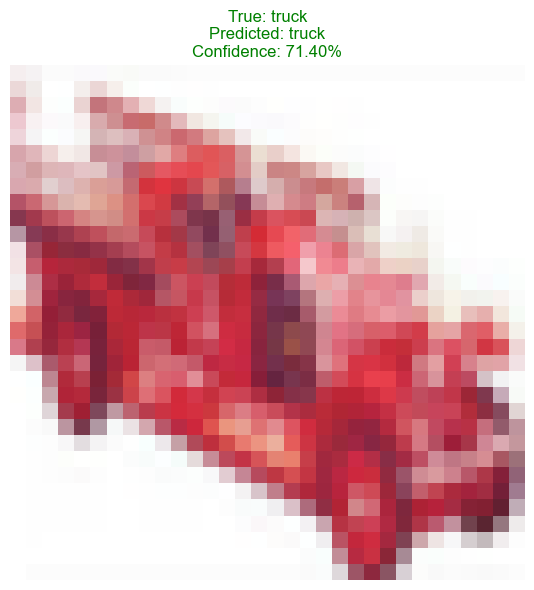

In [49]:
# Select a random test image
import random
random_index = random.randint(0, len(x_test) - 1)

# Get the image and true label
test_image = x_test[random_index]
true_label = class_names[y_true[random_index]]

# Prepare image for prediction
img = np.expand_dims(test_image, axis=0)

# Make prediction
prediction = model.predict(img, verbose=0)
prediction_probabilities = prediction.flatten()
predicted_class_index = np.argmax(prediction_probabilities)
predicted_class = class_names[predicted_class_index]
confidence = prediction_probabilities[predicted_class_index] * 100

# Plot image with prediction
plt.figure(figsize=(6, 6))
plt.imshow(test_image)
plt.axis('off')
color = 'green' if true_label == predicted_class else 'red'
plt.title(f'True: {true_label}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%', 
          fontsize=12, color=color)
plt.tight_layout()
plt.show()

This step is only to test the model on a single image. It shows the true label, predicted label, and how confident the model is about the image. The image is randomly chosen and later displayed on the screen. If the prediction is incorrect, the color will change to red. Prediction is based on the highest number from the array.

# 14. Step: MODEL IMPROVEMENT ANALYSIS

In [33]:
print("MODEL IMPROVEMENT ANALYSIS")


print("\n1. OVERALL PERFORMANCE:")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Best Validation Accuracy: {max(val_acc):.4f}")

print("\n2. CHALLENGES:")
print("   • Small image size (32x32) limits feature extraction")
print("   • Similar classes cause confusion (cat/dog, bird/airplane)")
print("   • Scared to have overfitting with deeper learning")

print("\n3. IMPROVEMENTS:")
print("   A) Architecture:")
print("      • Add more convolutional layers")
print("   B) Hyperparameters:")
print("      • Adjust learning rate: [0.01, 0.005, 0.001]")
print("      • Possibly increase dropout to 0.5")
print("   C) Data:")
print("      • More aggressive augmentation")
print("      • Try different augmentation")

print(f"\nModel weights saved to: {weightPath}")

MODEL IMPROVEMENT ANALYSIS

1. OVERALL PERFORMANCE:
   Test Accuracy: 0.8179 (81.79%)
   Test Loss: 0.5367
   Best Validation Accuracy: 0.8178

2. CHALLENGES:
   • Small image size (32x32) limits feature extraction
   • Similar classes cause confusion (cat/dog, bird/airplane)
   • Scared to have overfitting with deeper learning

3. IMPROVEMENTS:
   A) Architecture:
      • Add more convolutional layers
   B) Hyperparameters:
      • Adjust learning rate: [0.01, 0.005, 0.001]
      • Possibly increase dropout to 0.5
   C) Data:
      • More aggressive augmentation
      • Try different augmentation

Model weights saved to: best_weights_cifar10.weights.h5
